# Solving Linear Systems in Python
### MFAD Mini Project (UE25MA242A) – Application Problem 4
**Direct methods, accuracy & efficiency – and a real-world application: predicting car fuel efficiency by least squares**

*Team members: Varun C B · Vikhyath Varma D · Varshith Bhashyam · Ruthvik Reddy &nbsp;|&nbsp; Section: H*

---
### What this project does
| Part | Content |
|---|---|
| **Part A – Core Project 4** | Solve $Ax=b$ by `solve`, PLU, inverse, RREF, least-squares; compare **accuracy** and **speed**; handle square, over- and under-determined systems. |
| **Part B – Real-world application** | Real **Auto-MPG** data (392 cars) → matrix → full linear-algebra workflow → **predict mpg**. |

### Mapping to the department's workflow (Guidelines)
| Workflow stage | Linear-algebra component | Where |
|---|---|---|
| Real-world data | Auto-MPG dataset | B-Step 1 |
| Matrix representation | System of linear equations $Ax=b$ | B-Step 2 |
| Matrix simplification | Gaussian elimination / **RREF** / **LU** | A-Tasks 4,7 · B-Step 3 |
| Structure of the space | Column space, null space, **rank & nullity** | B-Step 4 |
| Remove redundancy | Linear independence → **basis selection** | B-Step 5 |
| Orthogonalization | **Gram–Schmidt** → orthonormal basis (QR) | B-Step 6 |
| Projection | Orthogonal projection onto Col(A) | B-Step 7 |
| Prediction / approximation | **Least-squares** solution | A-Task 9 · B-Step 8 |
| Pattern discovery | **Eigenvalues & eigenvectors** | B-Step 9 |
| System simplification | **Diagonalization** of a symmetric matrix | B-Step 10 |
| Final output | **Predicted mpg** | B-Final |

> Every step below follows the viva format **Concept → Purpose → Outcome**.

In [1]:
import time
import numpy as np
import pandas as pd
import scipy.linalg as sla
import matplotlib.pyplot as plt
from pathlib import Path

np.set_printoptions(precision=4, suppress=True, linewidth=120)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 140)
Path("figures").mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

def time_it(f, repeat=3):
    # best-of-`repeat` wall-clock time of f()
    best = np.inf
    for _ in range(repeat):
        t0 = time.perf_counter(); f(); best = min(best, time.perf_counter() - t0)
    return best

def rref(M, tol=1e-10):
    # Reduced row echelon form with partial pivoting.
    # tol is relative to max|M|; use tol=0 to test only for exact zero pivots.
    # Returns (R, pivot_columns).
    A = np.array(M, dtype=float)
    m, n = A.shape
    scale = max(1.0, np.abs(A).max())
    pivots, r = [], 0
    for c in range(n):
        if r >= m:
            break
        p = r + np.argmax(np.abs(A[r:, c]))
        if abs(A[p, c]) <= tol * scale:
            A[r:, c] = 0.0
            continue
        A[[r, p]] = A[[p, r]]
        A[r] = A[r] / A[r, c]
        rows = np.arange(m) != r
        A[rows] -= np.outer(A[rows, c], A[r])
        pivots.append(c)
        r += 1
    return A, pivots

---
# PART A – Core Project 4: Solving $Ax=b$ in Python
**Goal:** explore the built-in tools for solving linear systems and compare them in *accuracy* and *efficiency*.

> **Note on the textbook code:** a few snippets in the book's Project 4 do not run as printed
> (Task 4 calls `solve` again instead of using L and U; Task 10 pairs a 4×3 matrix with a length-3 vector, which is a shape error).
> They are corrected below, and each correction is marked **[fixed]**.

## Task 1 – Build the matrix $A$ and vector $b$

In [2]:
def create_magic_like(n):
    # Siamese-method magic square (n odd)
    magic = np.zeros((n, n), dtype=int)
    row, col, num = 0, n // 2, 1
    while num <= n * n:
        magic[row, col] = num
        num += 1
        new_row, new_col = (row - 1) % n, (col + 1) % n
        if magic[new_row, new_col]:
            row += 1
        else:
            row, col = new_row, new_col
    return magic

A = create_magic_like(5).astype(float)
b = np.array([10, 26, 42, 59, 38], dtype=float)
print("Matrix A:\n", A)
print("\nVector b:", b)
print(f"\nrank(A) = {np.linalg.matrix_rank(A)},  det(A) = {np.linalg.det(A):.2f},  cond(A) = {np.linalg.cond(A):.2f}")
print("-> square, full rank, well conditioned: Ax=b has a unique solution.")

Matrix A:
 [[17. 24.  1.  8. 15.]
 [23.  5.  7. 14. 16.]
 [ 4.  6. 13. 20. 22.]
 [10. 12. 19. 21.  3.]
 [11. 18. 25.  2.  9.]]

Vector b: [10. 26. 42. 59. 38.]

rank(A) = 5,  det(A) = 5070000.00,  cond(A) = 5.46
-> square, full rank, well conditioned: Ax=b has a unique solution.


## Task 2 – `numpy.linalg.solve`
**Concept:** `solve` calls LAPACK `gesv`, i.e. Gaussian elimination with partial pivoting (PLU).
**Purpose:** it is the recommended way to solve $Ax=b$ when nothing is known about the structure of $A$.

In [3]:
x = np.linalg.solve(A, b)
print("Solution x:", x)

Solution x: [-0.0083  0.0724  1.4718  1.4878 -0.3314]


## Task 3 – Residual $r = Ax-b$
**Concept:** the residual measures how well the computed $x$ satisfies the equations.
**Purpose:** the exact solution is unknown in practice, so a tiny residual is our accuracy check.

In [4]:
r = A @ x - b
print("Residual r =", r)
print(f"||r||_2 = {np.linalg.norm(r):.3e}   (≈ machine precision, so the solution is accurate)")

Residual r = [ 0.  0.  0.  0. -0.]
||r||_2 = 8.702e-15   (≈ machine precision, so the solution is accurate)


## Task 4 – PLU decomposition and triangular solves **[fixed]**
**Concept:** $A = PLU$ ($P$ permutation, $L$ lower-, $U$ upper-triangular). Then $Ax=b \iff L(Ux)=P^{T}b$:
solve $Ly=P^{T}b$ by *forward* substitution, then $Ux=y$ by *back* substitution.
**Purpose:** this is exactly what `solve` does internally – we reproduce it by hand to see the mechanism.

In [5]:
P, L, U = sla.lu(A)
print("P (permutation):\n", P)
print("\nL (lower triangular, unit diagonal):\n", L)
print("\nU (upper triangular):\n", U)
print("\nCheck  ||P L U - A|| =", np.linalg.norm(P @ L @ U - A))

y_fwd = sla.solve_triangular(L, P.T @ b, lower=True)    # forward substitution
x1    = sla.solve_triangular(U, y_fwd)                   # back substitution
err1  = x - x1
print("\nx1 (via L,U):", x1)
print("err1 = x - x1 =", err1, "   ||err1|| =", np.linalg.norm(err1))
print("residual ||A x1 - b|| =", np.linalg.norm(A @ x1 - b))

P (permutation):
 [[0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]]

L (lower triangular, unit diagonal):
 [[1.     0.     0.     0.     0.    ]
 [0.7391 1.     0.     0.     0.    ]
 [0.4783 0.7687 1.     0.     0.    ]
 [0.1739 0.2527 0.5164 1.     0.    ]
 [0.4348 0.4839 0.7231 0.9231 1.    ]]

U (upper triangular):
 [[ 23.       5.       7.      14.      16.    ]
 [  0.      20.3043  -4.1739  -2.3478   3.1739]
 [  0.       0.      24.8608  -2.8908  -1.0921]
 [  0.       0.       0.      19.6512  18.9793]
 [  0.       0.       0.       0.     -22.2222]]

Check  ||P L U - A|| = 1.9860273225978185e-15

x1 (via L,U): [-0.0083  0.0724  1.4718  1.4878 -0.3314]
err1 = x - x1 = [-0.  0.  0.  0. -0.]    ||err1|| = 3.574035584062971e-16
residual ||A x1 - b|| = 8.881784197001252e-15


## Task 5 – Least-squares function `lstsq` on a square system
**Concept:** `lstsq` minimises $\|Ax-b\|_2$ using the SVD. For a square non-singular $A$ the minimiser is the exact solution.

In [6]:
y_ls = np.linalg.lstsq(A, b, rcond=None)[0]
print("lstsq solution:", y_ls)
print("||x - y_ls|| =", np.linalg.norm(x - y_ls))

lstsq solution: [-0.0083  0.0724  1.4718  1.4878 -0.3314]
||x - y_ls|| = 4.231281802193935e-15


## Task 6 – Solving with the inverse $x=A^{-1}b$
**Concept:** $x=A^{-1}b$ is correct on paper, but computing $A^{-1}$ costs several times more than one LU solve (measured below: ~4x) and is less accurate on ill-conditioned problems.

In [7]:
A_inv = np.linalg.inv(A)
x2 = A_inv @ b
r2 = A @ x2 - b
err2 = x - x2
print("x2 (inverse):", x2)
print(f"||r2|| = {np.linalg.norm(r2):.3e}    ||err2 = x - x2|| = {np.linalg.norm(err2):.3e}")
print(f"(compare: ||r|| with solve = {np.linalg.norm(r):.3e})")

x2 (inverse): [-0.0083  0.0724  1.4718  1.4878 -0.3314]
||r2|| = 1.628e-14    ||err2 = x - x2|| = 8.216e-16
(compare: ||r|| with solve = 8.702e-15)


## Task 7 – Reduced row echelon form of $[A\,|\,b]$ (Gauss–Jordan)
**Concept:** RREF of the augmented matrix turns $[A|b]$ into $[I|x]$; the last column *is* the solution.
**Purpose:** shows elimination explicitly; it is also how we later detect pivots, rank and redundancy.

In [8]:
C = np.hstack([A, b[:, None]])
R, pivots = rref(C)
print("RREF of [A | b]:\n", R)
x3 = R[:, -1]
r3 = A @ x3 - b
err3 = x - x3
print("\nx3 (RREF):", x3)
print(f"||r3|| = {np.linalg.norm(r3):.3e}    ||err3|| = {np.linalg.norm(err3):.3e}")

RREF of [A | b]:
 [[ 1.      0.      0.      0.      0.     -0.0083]
 [ 0.      1.      0.      0.      0.      0.0724]
 [ 0.      0.      1.      0.      0.      1.4718]
 [ 0.      0.      0.      1.      0.      1.4878]
 [-0.     -0.     -0.     -0.      1.     -0.3314]]

x3 (RREF): [-0.0083  0.0724  1.4718  1.4878 -0.3314]
||r3|| = 8.882e-15    ||err3|| = 7.242e-16


### Summary of all five methods on the 5×5 system

In [9]:
summary = pd.DataFrame({
    "method":   ["np.linalg.solve", "PLU by hand", "lstsq (SVD)", "inverse  A⁻¹b", "RREF [A|b]"],
    "||residual||": [np.linalg.norm(A @ v - b) for v in (x, x1, y_ls, x2, x3)],
    "||x - x_solve||": [np.linalg.norm(x - v) for v in (x, x1, y_ls, x2, x3)],
})
summary

,method,||residual||,||x - x_solve||
0,np.linalg.solve,8.7023e-15,0.0000e+00
1,PLU by hand,8.8818e-15,3.5740e-16
2,lstsq (SVD),9.5131e-14,4.2313e-15
3,inverse A⁻¹b,1.6281e-14,8.2161e-16
4,RREF [A|b],8.8818e-15,7.2418e-16


## Task 8 – Efficiency (and accuracy) comparison: `solve` vs inverse vs RREF
**Concept:** cost of the three approaches grows like $O(n^3)$, but with very different constants (LAPACK vs a Python RREF).
We use a *diagonally dominant* random matrix (guaranteed non-singular), $n = 50 \ldots 500$.

In [10]:
rng = np.random.default_rng(0)
sizes = [50, 100, 200, 300, 400, 500]
t_solve, t_inv, t_rref = [], [], []
for N in sizes:
    An = rng.random((N, N)) + N * np.eye(N)
    bn = rng.random(N)
    t_solve.append(time_it(lambda: np.linalg.solve(An, bn)))
    t_inv.append(time_it(lambda: np.linalg.inv(An) @ bn))
    t_rref.append(time_it(lambda: rref(np.column_stack([An, bn]), tol=0.0)[0][:, -1], repeat=1))

timing = pd.DataFrame({"n": sizes, "solve (s)": t_solve, "inverse (s)": t_inv, "rref (s)": t_rref})
timing["inverse / solve"] = timing["inverse (s)"] / timing["solve (s)"]
timing["rref / solve"] = timing["rref (s)"] / timing["solve (s)"]
timing

,n,solve (s),inverse (s),rref (s),inverse / solve,rref / solve
0,50,2.4411e-05,7.6526e-05,0.0018,3.1349,72.3959
1,100,1.0740e-04,2.7842e-04,0.0039,2.5923,36.6715
2,200,3.8239e-04,1.6608e-03,0.0185,4.3432,48.4087
3,300,1.0841e-03,5.2319e-03,0.0861,4.8262,79.4512
4,400,2.0102e-03,8.7923e-03,0.2544,4.3739,126.5333
5,500,4.9879e-03,2.0218e-02,0.4648,4.0534,93.1893


### Accuracy on a hard problem – the Hilbert matrix
On a well-conditioned matrix every method looks fine. The **Hilbert matrix** $H_{ij}=1/(i+j-1)$ is notoriously ill-conditioned.
We choose $x_{true}=(1,\dots,1)$, set $b=Hx_{true}$, and measure the true error $\|x-x_{true}\|/\|x_{true}\|$.

 n  cond(H)  err solve  err inverse  err rref
 4 1.55e+04   3.37e-14     1.03e-12  1.20e-13
 5 4.77e+05   1.26e-12     2.70e-11  6.08e-13
 6 1.50e+07   4.08e-11     9.71e-10  1.84e-10
 7 4.75e+08   1.77e-09     1.03e-08  7.72e-09
 8 1.53e+10   3.71e-08     1.34e-06  1.40e-07
 9 4.93e+11   3.59e-06     3.76e-05  1.72e-06
10 1.60e+13   2.27e-05     3.57e-03  1.15e-05
11 5.22e+14   1.13e-03     9.99e-02  1.68e-03
12 1.64e+16   1.29e-01     3.25e+00  9.06e-02


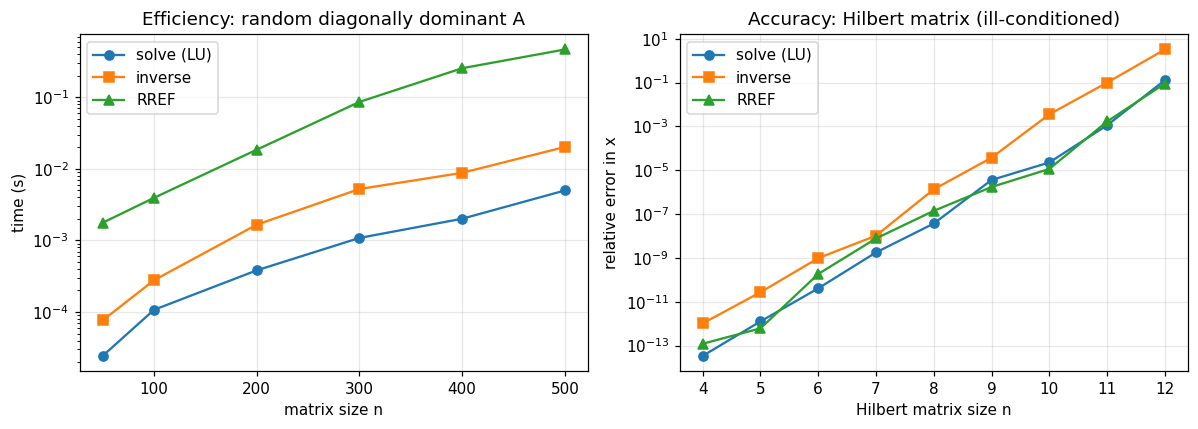


At n=500:  inverse is 4.1x slower and RREF is 93x slower than solve.


In [11]:
ns = list(range(4, 13))
err_solve, err_inv, err_rref, conds = [], [], [], []
for n in ns:
    H = sla.hilbert(n); xt = np.ones(n); bh = H @ xt
    err_solve.append(np.linalg.norm(np.linalg.solve(H, bh) - xt) / np.linalg.norm(xt))
    err_inv.append(np.linalg.norm(np.linalg.inv(H) @ bh - xt) / np.linalg.norm(xt))
    err_rref.append(np.linalg.norm(rref(np.column_stack([H, bh]), tol=0.0)[0][:, -1] - xt) / np.linalg.norm(xt))
    conds.append(np.linalg.cond(H))

hil = pd.DataFrame({"n": ns, "cond(H)": conds, "err solve": err_solve, "err inverse": err_inv, "err rref": err_rref})
print(hil.to_string(index=False, float_format=lambda v: f"{v:.2e}"))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(sizes, t_solve, "o-", label="solve (LU)")
ax[0].plot(sizes, t_inv, "s-", label="inverse")
ax[0].plot(sizes, t_rref, "^-", label="RREF")
ax[0].set_yscale("log"); ax[0].set_xlabel("matrix size n"); ax[0].set_ylabel("time (s)")
ax[0].set_title("Efficiency: random diagonally dominant A"); ax[0].legend()
ax[1].semilogy(ns, err_solve, "o-", label="solve (LU)")
ax[1].semilogy(ns, err_inv, "s-", label="inverse")
ax[1].semilogy(ns, err_rref, "^-", label="RREF")
ax[1].set_xlabel("Hilbert matrix size n"); ax[1].set_ylabel("relative error in x")
ax[1].set_title("Accuracy: Hilbert matrix (ill-conditioned)"); ax[1].legend()
plt.tight_layout(); plt.savefig("figures/fig1_efficiency_accuracy.png", dpi=160); plt.show()
print(f"\nAt n=500:  inverse is {t_inv[-1]/t_solve[-1]:.1f}x slower and RREF is {t_rref[-1]/t_solve[-1]:.0f}x slower than solve.")

## Task 9 – Over-determined system ($m>n$): least squares and the normal equations
**Concept:** when $Ax=b$ is inconsistent, minimise $\|Ax-b\|_2$. The minimiser satisfies the **normal equations** $A^{T}Ax=A^{T}b$,
i.e. the residual is *orthogonal* to the column space of $A$.

In [12]:
A9 = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 10], [9, 11, 12]], dtype=float)
b9 = np.array([1, 2, 3, 4], dtype=float)
print("A is", A9.shape, " rank =", np.linalg.matrix_rank(A9), "-> 4 equations, 3 unknowns (over-determined)")

x9 = np.linalg.lstsq(A9, b9, rcond=None)[0]
r9 = A9 @ x9 - b9
y9_inv   = np.linalg.inv(A9.T @ A9) @ (A9.T @ b9)        # normal equations via inverse (book version)
y9_solve = np.linalg.solve(A9.T @ A9, A9.T @ b9)          # normal equations via LU (preferred)

print("\nlstsq solution x :", x9)
print("residual r = Ax-b :", r9, "  (NOT zero: system is inconsistent)")
print("normal eq. (inv)  :", y9_inv)
print("normal eq. (solve):", y9_solve)
print(f"||x - y_inv|| = {np.linalg.norm(x9 - y9_inv):.2e},  ||x - y_solve|| = {np.linalg.norm(x9 - y9_solve):.2e}")
print("A^T r (should be ≈ 0, residual ⟂ Col(A)):", A9.T @ r9)

A is (4, 3)  rank = 3 -> 4 equations, 3 unknowns (over-determined)

lstsq solution x : [-0.2463  0.3892  0.1626]
residual r = Ax-b : [ 0.0197 -0.064   0.0148  0.0148]   (NOT zero: system is inconsistent)
normal eq. (inv)  : [-0.2463  0.3892  0.1626]
normal eq. (solve): [-0.2463  0.3892  0.1626]
||x - y_inv|| = 5.25e-14,  ||x - y_solve|| = 2.10e-14
A^T r (should be ≈ 0, residual ⟂ Col(A)): [0. 0. 0.]


## Task 10 – Under-determined system ($m<n$): infinitely many solutions **[fixed]**
**Concept:** with $\text{rank}(A)=2<n=4$ the null space has dimension $n-\text{rank}=2$. Every solution is
$x = x_p + c_1 n_1 + c_2 n_2$ where $n_i$ span $\text{Null}(A)$.
The **pseudoinverse** gives the particular solution of *minimum norm*.
*(The book prints a 4×3 matrix with a length-3 vector – a shape error. We use its transpose, a 3×4 matrix, which is what the task intends.)*

In [13]:
A10 = np.array([[1, 4, 7, 10], [2, 5, 8, 11], [3, 6, 9, 12]], dtype=float)
b10 = np.array([1, 3, 5], dtype=float)
print("A is", A10.shape, " rank =", np.linalg.matrix_rank(A10))

# consistency + free variables from RREF of the augmented matrix
Rg, pv = rref(np.column_stack([A10, b10]))
print("\nRREF [A|b]:\n", Rg)
print("pivot columns:", pv, "-> columns", [c for c in range(4) if c not in pv], "are free; last row is 0=0, so the system is consistent")

x10 = np.linalg.lstsq(A10, b10, rcond=None)[0]
y10 = np.linalg.pinv(A10) @ b10
print("\nlstsq solution:", x10, " residual norm =", np.linalg.norm(A10 @ x10 - b10))
print("pinv  solution:", y10, " residual norm =", np.linalg.norm(A10 @ y10 - b10))
print("(numpy's lstsq already returns the minimum-norm solution, so both agree)")

N10 = sla.null_space(A10)
print("\nBasis of Null(A) (columns):\n", N10)
for Cc in (np.array([1, 2]), np.array([-3, 0.5])):
    z = x10 + N10 @ Cc
    print(f"C={Cc}: z = {z},  ||Az-b|| = {np.linalg.norm(A10 @ z - b10):.1e},  ||z|| = {np.linalg.norm(z):.3f}  (>= ||x_min|| = {np.linalg.norm(x10):.3f})")

A is (3, 4)  rank = 2

RREF [A|b]:
 [[ 1.      0.     -1.     -2.      2.3333]
 [ 0.      1.      2.      3.     -0.3333]
 [ 0.      0.      0.      0.      0.    ]]
pivot columns: [0, 1] -> columns [2, 3] are free; last row is 0=0, so the system is consistent

lstsq solution: [ 1.5     0.8333  0.1667 -0.5   ]  residual norm = 5.634860374059478e-15
pinv  solution: [ 1.5     0.8333  0.1667 -0.5   ]  residual norm = 6.217248937900877e-15
(numpy's lstsq already returns the minimum-norm solution, so both agree)

Basis of Null(A) (columns):
 [[-0.541  -0.0856]
 [ 0.6575  0.5174]
 [ 0.308  -0.7779]
 [-0.4245  0.3461]]
C=[1 2]: z = [ 0.7877  2.5256 -1.0812 -0.2322],  ||Az-b|| = 6.9e-15,  ||z|| = 2.867  (>= ||x_min|| = 1.795)
C=[-3.   0.5]: z = [ 3.0801 -0.8804 -1.1462  0.9465],  ||Az-b|| = 2.0e-14,  ||z|| = 3.532  (>= ||x_min|| = 1.795)


---
# PART B – Real-world application: predicting car fuel efficiency
**Problem.** Given a car's specifications (cylinders, displacement, horsepower, weight, acceleration, model year), predict its
fuel efficiency in **miles per gallon (mpg)**.

Each car gives one linear equation, so $n$ cars give a (huge) **over-determined linear system** $Ax=b$ – exactly the
situation of Task 9. We now push it through the department's complete workflow.

## Step 1 – Real-world data
**Data:** *Auto-MPG* (UCI Machine Learning Repository; 1970–82 cars). File: `data/auto-mpg.csv`.

In [14]:
df_raw = pd.read_csv("data/auto-mpg.csv")
print("raw shape:", df_raw.shape)
print("missing values:\n", df_raw.isna().sum()[lambda s: s > 0])
df = df_raw.dropna().reset_index(drop=True)
print("\nafter dropping rows with missing horsepower:", df.shape)
df.head()

raw shape: (398, 9)
missing values:
 horsepower    6
dtype: int64

after dropping rows with missing horsepower: (392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## Step 2 – Matrix representation  ($Ax=b$)
**Concept:** a data table is a matrix; a linear model is a linear system.
- Row $i$ of $A$: $[\,1,\ \text{cyl}_i,\ \text{disp}_i,\ \text{hp}_i,\ \text{weight}_i,\ \text{accel}_i,\ \text{year}_i\,]$ (the 1 is for the intercept).
- $b$: the measured mpg of car $i$.  $x$: unknown coefficients.

We also keep **weight in kg** as an 8th column. Real datasets often carry the same quantity in two units;
this deliberately gives us a *redundant* column to detect in Steps 3–5.

In [15]:
KG = 0.45359237  # kg per lb
FEATS = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
cols = ["intercept", "cylinders", "displacement", "horsepower", "weight_lb", "acceleration", "model_year", "weight_kg"]

A_full = np.column_stack([np.ones(len(df)), df[FEATS].values, df["weight"].values * KG])
b_mpg = df["mpg"].values
print(f"A_full is {A_full.shape[0]} x {A_full.shape[1]}  ->  {A_full.shape[0]} equations, {A_full.shape[1]} unknowns")
print("b (mpg) has length", b_mpg.size)
pd.DataFrame(A_full[:5], columns=cols)

A_full is 392 x 8  ->  392 equations, 8 unknowns
b (mpg) has length 392


,intercept,cylinders,displacement,horsepower,weight_lb,acceleration,model_year,weight_kg
0,1.0,8.0,307.0,130.0,3504.0,12.0,70.0,1589.3877
1,1.0,8.0,350.0,165.0,3693.0,11.5,70.0,1675.1166
2,1.0,8.0,318.0,150.0,3436.0,11.0,70.0,1558.5434
3,1.0,8.0,304.0,150.0,3433.0,12.0,70.0,1557.1826
4,1.0,8.0,302.0,140.0,3449.0,10.5,70.0,1564.4401


## Step 3 – Matrix simplification (RREF / Gaussian elimination)
**Concept:** row-reduce $A$ to RREF; the **pivot columns** are the independent columns.
**Purpose:** find out whether every column carries new information.

In [16]:
R_full, piv_full = rref(A_full)
print("pivot columns:", piv_full, "->", [cols[i] for i in piv_full])
print("non-pivot column(s):", [cols[i] for i in range(8) if i not in piv_full])
print("\nTop 8 rows of RREF(A_full):")
print((pd.DataFrame(R_full[:8], columns=cols).round(4) + 0.0).to_string())
rk = len(piv_full)
j_kg = 7; j_lb = piv_full.index(4)
print(f"\nOutcome: rank = {rk} < 8 columns. The weight_kg column is NOT a pivot; its RREF column reads "
      f"weight_kg = {R_full[j_lb, j_kg]:.5f} x weight_lb  (the lb->kg conversion factor {KG}).")

pivot columns: [0, 1, 2, 3, 4, 5, 6] -> ['intercept', 'cylinders', 'displacement', 'horsepower', 'weight_lb', 'acceleration', 'model_year']
non-pivot column(s): ['weight_kg']

Top 8 rows of RREF(A_full):
   intercept  cylinders  displacement  horsepower  weight_lb  acceleration  model_year  weight_kg
0        1.0        0.0           0.0         0.0        0.0           0.0         0.0     0.0000
1        0.0        1.0           0.0         0.0        0.0           0.0         0.0     0.0000
2        0.0        0.0           1.0         0.0        0.0           0.0         0.0     0.0000
3        0.0        0.0           0.0         1.0        0.0           0.0         0.0     0.0000
4        0.0        0.0           0.0         0.0        1.0           0.0         0.0     0.4536
5        0.0        0.0           0.0         0.0        0.0           1.0         0.0     0.0000
6        0.0        0.0           0.0         0.0        0.0           0.0         1.0     0.0000
7        0.0

## Step 4 – Structure of the space: column space, null space, rank & nullity
**Concept:** rank = dim Col(A); nullity = (#columns) − rank; $\text{Null}(A)$ holds every linear dependency among columns.
**Purpose:** quantify *how much* redundancy exists and *what* it is.

In [17]:
m, n_cols = A_full.shape
rank = np.linalg.matrix_rank(A_full)
nullity = n_cols - rank
print(f"rank(A) = {rank},  nullity = {nullity}   (rank + nullity = {rank + nullity} = number of columns)")
print(f"Four fundamental subspaces:  dim Col(A) = {rank}, dim Row(A) = {rank}, dim Null(A) = {nullity}, dim Null(A^T) = {m - rank}")

Nsp = sla.null_space(A_full)[:, 0]
Nsp = Nsp / Nsp[4]                       # scale so that weight_lb has coefficient 1
print("\nNull-space vector (scaled):")
print((pd.Series(Nsp, index=cols).round(4) + 0.0).to_string())
print(f"\nOutcome: 1*weight_lb + ({Nsp[7]:.4f})*weight_kg = 0, i.e. weight_lb = {-Nsp[7]:.4f} * weight_kg  (1 kg = 2.2046 lb).")
print(f"cond(A_full) = {np.linalg.cond(A_full):.2e}  (huge -> A_full is numerically singular)")

rank(A) = 7,  nullity = 1   (rank + nullity = 8 = number of columns)
Four fundamental subspaces:  dim Col(A) = 7, dim Row(A) = 7, dim Null(A) = 1, dim Null(A^T) = 385

Null-space vector (scaled):
intercept       0.0000
cylinders       0.0000
displacement    0.0000
horsepower      0.0000
weight_lb       1.0000
acceleration    0.0000
model_year      0.0000
weight_kg      -2.2046

Outcome: 1*weight_lb + (-2.2046)*weight_kg = 0, i.e. weight_lb = 2.2046 * weight_kg  (1 kg = 2.2046 lb).
cond(A_full) = 1.97e+16  (huge -> A_full is numerically singular)


## Step 5 – Remove redundancy: linear independence → basis selection
**Concept:** the pivot columns form a **basis** of Col(A).
**Purpose:** a unique least-squares solution exists only if the columns are linearly independent.

In [18]:
A = A_full[:, piv_full]
names = [cols[i] for i in piv_full]
print("Basis (kept) columns:", names)
print(f"A is now {A.shape[0]} x {A.shape[1]},  rank = {np.linalg.matrix_rank(A)} = #columns  ->  columns are linearly independent")
print(f"cond(A) = {np.linalg.cond(A):.3e}   cond(A^T A) = {np.linalg.cond(A.T @ A):.3e}   (cond(A^T A) = cond(A)^2)")

Basis (kept) columns: ['intercept', 'cylinders', 'displacement', 'horsepower', 'weight_lb', 'acceleration', 'model_year']
A is now 392 x 7,  rank = 7 = #columns  ->  columns are linearly independent
cond(A) = 8.530e+04   cond(A^T A) = 7.277e+09   (cond(A^T A) = cond(A)^2)


## Step 6 – Orthogonalization: Gram–Schmidt → orthonormal basis (QR)
**Concept:** Gram–Schmidt converts independent columns $a_1,\dots,a_n$ into orthonormal $q_1,\dots,q_n$ with $A=QR$
($R$ upper triangular). $q_j = \dfrac{a_j-\sum_{i<j}(q_i^{T}a_j)q_i}{\|\cdot\|}$.
**Purpose:** orthonormal columns make projections trivial ($QQ^{T}$) and avoid forming $A^{T}A$.
We implement *classical* and *modified* Gram–Schmidt and compare their loss of orthogonality with Householder QR (`np.linalg.qr`).

In [19]:
def gram_schmidt_classical(A):
    m, n = A.shape
    Q = np.zeros((m, n)); R = np.zeros((n, n))
    for j in range(n):
        v = A[:, j].copy()
        for i in range(j):
            R[i, j] = Q[:, i] @ A[:, j]
            v -= R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(v); Q[:, j] = v / R[j, j]
    return Q, R

def gram_schmidt_modified(A):
    m, n = A.shape
    Q = A.astype(float).copy(); R = np.zeros((n, n))
    for j in range(n):
        R[j, j] = np.linalg.norm(Q[:, j]); Q[:, j] /= R[j, j]
        for k in range(j + 1, n):
            R[j, k] = Q[:, j] @ Q[:, k]; Q[:, k] -= R[j, k] * Q[:, j]
    return Q, R

I7 = np.eye(A.shape[1])
rows = []
for name, fn in [("Classical Gram-Schmidt", gram_schmidt_classical),
                 ("Modified Gram-Schmidt", gram_schmidt_modified),
                 ("Householder QR (numpy)", np.linalg.qr)]:
    Qx, Rx = fn(A)
    rows.append([name, np.linalg.norm(Qx.T @ Qx - I7), np.linalg.norm(Qx @ Rx - A) / np.linalg.norm(A)])
print(pd.DataFrame(rows, columns=["method", "||Q^T Q - I||", "||QR - A|| / ||A||"]).to_string(index=False, float_format=lambda v: f"{v:.2e}"))

Q, R = gram_schmidt_modified(A)       # the orthonormal basis used from here on
print("\nR (upper triangular) diagonal:", np.diag(R))
print(f"Outcome: Q is a {Q.shape[0]}x{Q.shape[1]} matrix with orthonormal columns (Q^T Q = I up to {np.linalg.norm(Q.T@Q-I7):.0e}), A = QR.")

                method  ||Q^T Q - I||  ||QR - A|| / ||A||
Classical Gram-Schmidt       2.59e-13            8.80e-17
 Modified Gram-Schmidt       1.74e-14            1.18e-16
Householder QR (numpy)       4.72e-15            6.32e-16

R (upper triangular) diagonal: [  19.799    33.7297  640.9016  335.1113 5919.1912   33.7708   65.2863]
Outcome: Q is a 392x7 matrix with orthonormal columns (Q^T Q = I up to 2e-14), A = QR.


## Step 7 – Projection onto the column space
**Concept:** the orthogonal projection of $b$ onto $\text{Col}(A)$ is $\hat b = Pb$ with $P = QQ^{T} = A(A^{T}A)^{-1}A^{T}$.
**Purpose:** $\hat b$ is the closest vector to $b$ that a linear model can reproduce; the leftover $e=b-\hat b$ is the error.

In [20]:
P_proj = Q @ Q.T                       # 392 x 392 projection matrix
b_hat = P_proj @ b_mpg                 # projection of mpg onto Col(A)
e = b_mpg - b_hat                      # error vector

print("P is symmetric          :", np.allclose(P_proj, P_proj.T))
print("P is idempotent (P^2=P) :", np.allclose(P_proj @ P_proj, P_proj))
print(f"trace(P) = {np.trace(P_proj):.4f}  (= rank = {A.shape[1]})")
print(f"||A^T e|| / (||A|| ||e||) = {np.linalg.norm(A.T @ e) / (np.linalg.norm(A) * np.linalg.norm(e)):.2e}   (error is orthogonal to every column of A)")
print(f"Pythagoras: ||b||^2 = {b_mpg @ b_mpg:.2f}  =  ||b_hat||^2 + ||e||^2 = {b_hat @ b_hat + e @ e:.2f}")
print(f"\nOutcome: projection explains {1 - (e @ e) / np.sum((b_mpg - b_mpg.mean())**2):.1%} of the variance of mpg (R^2 on all data).")

P is symmetric          : True
P is idempotent (P^2=P) : True
trace(P) = 7.0000  (= rank = 7)
||A^T e|| / (||A|| ||e||) = 6.78e-15   (error is orthogonal to every column of A)
Pythagoras: ||b||^2 = 239305.74  =  ||b_hat||^2 + ||e||^2 = 239305.74

Outcome: projection explains 80.9% of the variance of mpg (R^2 on all data).


## Step 8 – Prediction / approximation: the least-squares solution
**Concept:** $\hat x = \arg\min \|Ax-b\|_2$, found from $A^{T}A\hat x = A^{T}b$ (normal equations) – a **square, symmetric** system,
so every method of **Part A** applies. QR gives $R\hat x = Q^{T}b$; SVD (`lstsq`) is the most robust.
**Purpose:** obtain the coefficients that turn specifications into predicted mpg.
### 8a – Six ways to compute $\hat x$ on the full data

In [21]:
G, c = A.T @ A, A.T @ b_mpg                      # normal equations  G x = c

def ls_normal_lu():
    Pp, Ll, Uu = sla.lu(G)
    return sla.solve_triangular(Uu, sla.solve_triangular(Ll, Pp.T @ c, lower=True))
def ls_normal_inv():  return np.linalg.inv(G) @ c
def ls_normal_rref(): return rref(np.column_stack([G, c]), tol=0.0)[0][:, -1]
def ls_qr():          return sla.solve_triangular(R, Q.T @ b_mpg)
def ls_svd():         return np.linalg.lstsq(A, b_mpg, rcond=None)[0]

methods = {"Normal eq. + PLU": ls_normal_lu, "Normal eq. + inverse": ls_normal_inv, "Normal eq. + RREF": ls_normal_rref,
           "QR (Gram-Schmidt)": ls_qr, "SVD  (lstsq)": ls_svd}
x_ref = ls_svd()
rows = []
for name, f in methods.items():
    xx = f()
    rows.append([name, time_it(f, 20), np.linalg.norm(xx - x_ref) / np.linalg.norm(x_ref), np.linalg.norm(A @ xx - b_mpg)])
print(pd.DataFrame(rows, columns=["method", "time (s)", "rel. diff vs SVD", "||Ax-b||"]).to_string(index=False, float_format=lambda v: f"{v:.2e}"))

x_all = x_ref.copy()
print("\nLeast-squares coefficients (all 392 cars):")
print(pd.Series(x_all, index=names).round(6).to_string())

              method  time (s)  rel. diff vs SVD  ||Ax-b||
    Normal eq. + PLU  2.65e-05          2.04e-13  6.74e+01
Normal eq. + inverse  4.30e-06          1.46e-13  6.74e+01
   Normal eq. + RREF  7.24e-05          3.15e-14  6.74e+01
   QR (Gram-Schmidt)  9.10e-06          4.62e-13  6.74e+01
        SVD  (lstsq)  2.02e-05          0.00e+00  6.74e+01

Least-squares coefficients (all 392 cars):
intercept      -14.5352
cylinders       -0.3299
displacement     0.0077
horsepower      -0.0004
weight_lb       -0.0068
acceleration     0.0853
model_year       0.7534


**What if we had *not* removed the redundant column?** The full matrix has no unique solution; the pseudoinverse (Task 10) picks the minimum-norm one:

In [22]:
x_pinv = np.linalg.pinv(A_full) @ b_mpg
print(pd.DataFrame({"A (7 cols)": list(x_all) + [np.nan], "A_full via pinv (8 cols)": x_pinv}, index=cols).round(6).to_string())
print("\nsame predictions? max |A_full x_pinv - A x_all| =", np.abs(A_full @ x_pinv - A @ x_all).max())
print("Outcome: predictions are identical (same projection), but the weight effect is split between lb and kg columns -> redundancy hurts interpretability.")

              A (7 cols)  A_full via pinv (8 cols)
intercept       -14.5352                  -14.5352
cylinders        -0.3299                   -0.3299
displacement      0.0077                    0.0077
horsepower       -0.0004                   -0.0004
weight_lb        -0.0068                   -0.0056
acceleration      0.0853                    0.0853
model_year        0.7534                    0.7534
weight_kg            NaN                   -0.0026

same predictions? max |A_full x_pinv - A x_all| = 4.405364961712621e-13
Outcome: predictions are identical (same projection), but the weight effect is split between lb and kg columns -> redundancy hurts interpretability.


### 8b – Predictive accuracy on unseen cars (80 / 20 train–test split)

In [23]:
rs = np.random.default_rng(42)
perm = rs.permutation(len(b_mpg))
n_tr = int(0.8 * len(perm))
train_idx, test_idx = perm[:n_tr], perm[n_tr:]
A_tr, A_te, b_tr, b_te = A[train_idx], A[test_idx], b_mpg[train_idx], b_mpg[test_idx]

Q_tr, R_tr = np.linalg.qr(A_tr)
x_tr = sla.solve_triangular(R_tr, Q_tr.T @ b_tr)            # least squares on TRAIN only

def metrics(y, yh):
    return dict(RMSE=np.sqrt(np.mean((y - yh) ** 2)), MAE=np.mean(np.abs(y - yh)), R2=1 - np.sum((y - yh) ** 2) / np.sum((y - y.mean()) ** 2))

res = pd.DataFrame({"train": metrics(b_tr, A_tr @ x_tr), "test": metrics(b_te, A_te @ x_tr)}).T
print(f"train = {len(train_idx)} cars, test = {len(test_idx)} cars")
print(res.round(4).to_string())

mpg_eq = " ".join(f"{v:+.4g}*{nm}" for nm, v in zip(names, x_tr))
print("\nFitted model:\n  mpg =", mpg_eq)

try:                                  # optional cross-check against scikit-learn
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression().fit(A_tr[:, 1:], b_tr)
    print("\nscikit-learn check, max |coef diff| =", np.abs(lr.coef_ - x_tr[1:]).max())
except ImportError:
    pass

print("\nNote: compare with Step 8a (all data). horsepower: {:+.4f} (all) vs {:+.4f} (train only) - the coefficient even changes sign.".format(x_all[3], x_tr[3]))
print("This instability is the symptom of correlated features (see Step 9): individual coefficients are fragile, predictions are not.")

train = 313 cars, test = 79 cars
         RMSE     MAE      R2
train  3.3617  2.6118  0.8172
test   3.6050  2.6855  0.7687

Fitted model:
  mpg = -14.77*intercept -0.2035*cylinders +0.006423*displacement +0.008326*horsepower -0.007356*weight_lb +0.135*acceleration +0.7495*model_year



scikit-learn check, max |coef diff| = 3.913536161803677e-15

Note: compare with Step 8a (all data). horsepower: -0.0004 (all) vs +0.0083 (train only) - the coefficient even changes sign.
This instability is the symptom of correlated features (see Step 9): individual coefficients are fragile, predictions are not.


## Step 9 – Pattern discovery: eigenvalues & eigenvectors
**Concept:** for the symmetric correlation matrix $C$ of the 6 features, $Cv=\lambda v$. Eigenvectors are directions of variation;
eigenvalues say how much variance each direction carries.
**Purpose:** reveal *why* the system was ill-conditioned – the features are strongly inter-correlated (big engines are heavy and powerful).

In [24]:
Xf = df[FEATS].values
Zf = (Xf - Xf.mean(0)) / Xf.std(0, ddof=1)
C_corr = Zf.T @ Zf / (len(Zf) - 1)                         # correlation matrix (symmetric)
lam_all, V_all = np.linalg.eigh(C_corr)
order = np.argsort(lam_all)[::-1]; lam_all, V_all = lam_all[order], V_all[:, order]

print("Eigenvalues:", lam_all)
print("Explained variance ratio:", lam_all / lam_all.sum())
print("Cumulative:", np.cumsum(lam_all) / lam_all.sum())
print("\nEigenvectors (loadings) of the first two principal directions:")
print(pd.DataFrame(V_all[:, :2], index=FEATS, columns=["PC1", "PC2"]).round(3).to_string())
print(f"\ncondition number of C = lambda_max / lambda_min = {lam_all[0] / lam_all[-1]:.1f}")
print(f"Outcome: the first eigen-direction alone carries {lam_all[0] / lam_all.sum():.1%} of the variance -> one 'size / power' factor dominates;"
      f"\n         it loads on cylinders, displacement, horsepower and weight with the same sign.")

Eigenvalues: [4.2572 0.8396 0.6728 0.1329 0.0612 0.0364]
Explained variance ratio: [0.7095 0.1399 0.1121 0.0221 0.0102 0.0061]
Cumulative: [0.7095 0.8495 0.9616 0.9837 0.9939 1.    ]

Eigenvectors (loadings) of the first two principal directions:
                PC1    PC2
cylinders    -0.455 -0.189
displacement -0.469 -0.163
horsepower   -0.464 -0.011
weight       -0.446 -0.257
acceleration  0.325 -0.221
model_year    0.232 -0.907

condition number of C = lambda_max / lambda_min = 117.0
Outcome: the first eigen-direction alone carries 71.0% of the variance -> one 'size / power' factor dominates;
         it loads on cylinders, displacement, horsepower and weight with the same sign.


## Step 10 – System simplification: diagonalization of a symmetric matrix
**Concept:** the spectral theorem: $C = V\Lambda V^{T}$ with orthogonal $V$ and diagonal $\Lambda$. In the eigenbasis the coupled normal equations
$C\beta = \rho$ decouple into scalar equations $\lambda_i \tilde\beta_i = \tilde\rho_i$, so $\beta = V\Lambda^{-1}V^{T}\rho$.
**Purpose:** (i) solve the system trivially; (ii) *simplify the model* by dropping directions with tiny $\lambda$ (Principal Component Regression) – this reduces noise.

Diagonalization check  ||V diag(lam) V^T - C|| = 1.0244326907395807e-14
V orthogonal           ||V^T V - I||        = 2.672178278807195e-15

Diagonalization solution == QR least-squares from Step 8b ? True
 directions kept k  test RMSE
                 1     4.1376
                 2     3.8594
                 3     3.6231
                 4     3.5688
                 5     3.6481
                 6     3.6050

Outcome: all 6 directions give test RMSE = 3.605 mpg; the best simplified model keeps k = 4 directions (RMSE = 3.569). Dropping the tiny-eigenvalue, near-collinear directions simplifies the model without hurting accuracy.


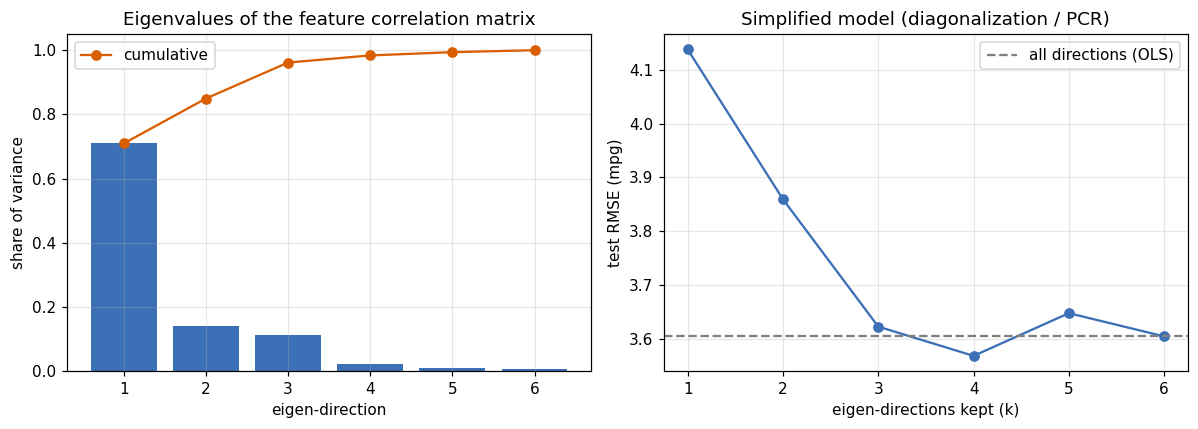

In [25]:
# Fit on TRAIN only (no leakage): standardise with train statistics
Xtr, Xte = df[FEATS].values[train_idx], df[FEATS].values[test_idx]
mu, sd = Xtr.mean(0), Xtr.std(0, ddof=1)
Ztr, Zte = (Xtr - mu) / sd, (Xte - mu) / sd
ybar = b_tr.mean()
C_tr = Ztr.T @ Ztr / (len(Ztr) - 1)
rho = Ztr.T @ (b_tr - ybar) / (len(Ztr) - 1)

lam, V = np.linalg.eigh(C_tr); o = np.argsort(lam)[::-1]; lam, V = lam[o], V[:, o]
print("Diagonalization check  ||V diag(lam) V^T - C|| =", np.linalg.norm(V @ np.diag(lam) @ V.T - C_tr))
print("V orthogonal           ||V^T V - I||        =", np.linalg.norm(V.T @ V - np.eye(6)))

def pcr(k):
    beta = V[:, :k] @ ((V[:, :k].T @ rho) / lam[:k])         # keep k largest eigen-directions
    return beta

# k = 6 (all directions) must reproduce ordinary least squares from Step 8b
beta6 = pcr(6)
coef_raw = beta6 / sd
icpt = ybar - coef_raw @ mu
print("\nDiagonalization solution == QR least-squares from Step 8b ?",
      np.allclose(np.r_[icpt, coef_raw], x_tr, rtol=1e-6, atol=1e-8))

ks = np.arange(1, 7)
rmse_k = [np.sqrt(np.mean((b_te - (ybar + Zte @ pcr(k))) ** 2)) for k in ks]
print(pd.DataFrame({"directions kept k": ks, "test RMSE": rmse_k}).round(4).to_string(index=False))
rmse_ols = res.loc["test", "RMSE"]
kbest = int(ks[int(np.argmin(rmse_k))])
print(f"\nOutcome: all 6 directions give test RMSE = {rmse_ols:.3f} mpg; the best simplified model keeps k = {kbest} directions "
      f"(RMSE = {min(rmse_k):.3f}). Dropping the tiny-eigenvalue, near-collinear directions simplifies the model without hurting accuracy.")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(range(1, 7), lam_all / lam_all.sum(), color="#3b6fb6")
ax[0].plot(range(1, 7), np.cumsum(lam_all) / lam_all.sum(), "o-", color="#d95f02", label="cumulative")
ax[0].set_xlabel("eigen-direction"); ax[0].set_ylabel("share of variance"); ax[0].set_title("Eigenvalues of the feature correlation matrix"); ax[0].legend()
ax[1].plot(ks, rmse_k, "o-", color="#3b6fb6"); ax[1].axhline(rmse_ols, ls="--", color="gray", label="all directions (OLS)")
ax[1].set_xlabel("eigen-directions kept (k)"); ax[1].set_ylabel("test RMSE (mpg)"); ax[1].set_title("Simplified model (diagonalization / PCR)"); ax[1].legend()
plt.tight_layout(); plt.savefig("figures/fig3_eigen_pcr.png", dpi=160); plt.show()

---
# FINAL APPLICATION OUTPUT – the mpg predictor

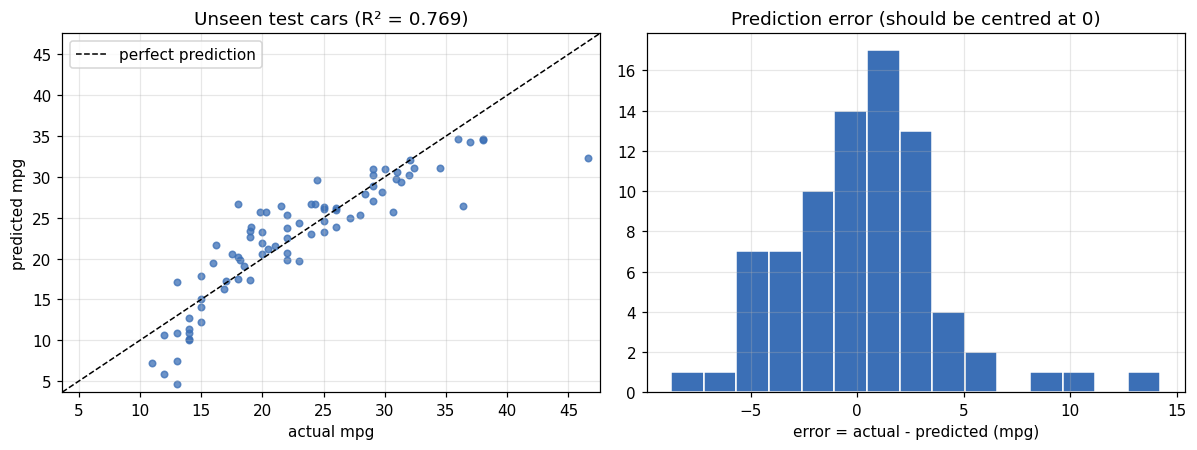

,name,weight,horsepower,model_year,actual mpg,predicted mpg,error
0,chrysler newport royal,4422,190.0,72,13.0,10.88,2.12
1,volvo diesel,3160,76.0,81,30.7,25.68,5.02
2,amc hornet,2901,100.0,74,19.0,22.62,-3.62
3,volvo 244dl,2945,98.0,75,22.0,22.52,-0.52
4,buick skylark,3425,105.0,77,20.5,21.17,-0.67
5,datsun 310 gx,1995,67.0,82,38.0,34.53,3.47
6,opel manta,2158,75.0,73,24.0,26.72,-2.72
7,plymouth satellite custom (sw),4077,150.0,72,14.0,12.76,1.24


In [26]:
pred_te = A_te @ x_tr
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].scatter(b_te, pred_te, s=18, alpha=0.75, color="#3b6fb6")
lim = [min(b_te.min(), pred_te.min()) - 1, max(b_te.max(), pred_te.max()) + 1]
ax[0].plot(lim, lim, "k--", lw=1, label="perfect prediction"); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("actual mpg"); ax[0].set_ylabel("predicted mpg"); ax[0].set_title(f"Unseen test cars (R² = {res.loc['test','R2']:.3f})"); ax[0].legend()
ax[1].hist(b_te - pred_te, bins=15, color="#3b6fb6", edgecolor="white")
ax[1].set_xlabel("error = actual - predicted (mpg)"); ax[1].set_title("Prediction error (should be centred at 0)")
plt.tight_layout(); plt.savefig("figures/fig2_pred_vs_actual.png", dpi=160); plt.show()

sample = df.iloc[test_idx][["name", "weight", "horsepower", "model_year"]].copy().head(8)
sample["actual mpg"] = b_te[:8]; sample["predicted mpg"] = pred_te[:8]
sample["error"] = sample["actual mpg"] - sample["predicted mpg"]
sample.round(2).reset_index(drop=True)

In [27]:
def predict_mpg(cylinders, displacement, horsepower, weight_lb, acceleration, model_year):
    # Predict mpg with the least-squares model fitted on all 392 cars (Step 8a)
    v = np.array([1, cylinders, displacement, horsepower, weight_lb, acceleration, model_year], dtype=float)
    return float(v @ x_all)

# --- live-demo examples ---
print(f"Small 4-cyl 1980 car  (140 cu.in, 90 hp, 2500 lb): {predict_mpg(4, 140, 90, 2500, 15.5, 80):.1f} mpg")
print(f"Big V8 1971 car       (400 cu.in, 200 hp, 4500 lb): {predict_mpg(8, 400, 200, 4500, 11.0, 71):.1f} mpg")

Small 4-cyl 1980 car  (140 cu.in, 90 hp, 2500 lb): 29.8 mpg
Big V8 1971 car       (400 cu.in, 200 hp, 4500 lb): 9.7 mpg


## Summary of results

In [28]:
print("PART A  (5x5 system):  solve / PLU / lstsq / inverse / RREF all agree to ~1e-13 on a well-conditioned matrix.")
print(f"        n=500 timing:  inverse = {t_inv[-1]/t_solve[-1]:.1f}x, RREF = {t_rref[-1]/t_solve[-1]:.0f}x the time of solve.")
print(f"        Hilbert n=10:  error  solve = {err_solve[6]:.1e},  inverse = {err_inv[6]:.1e},  RREF = {err_rref[6]:.1e}.")
print(f"PART B  (Auto-MPG):    A_full {A_full.shape} has rank {rank} (nullity {nullity}: weight_lb = 2.2046*weight_kg) -> basis of {A.shape[1]} columns.")
print(f"        QR/Gram-Schmidt -> projection -> least squares;  test RMSE = {res.loc['test','RMSE']:.2f} mpg, R^2 = {res.loc['test','R2']:.3f}.")
print(f"        Eigenvalues: first direction explains {lam_all[0]/lam_all.sum():.0%} of feature variance (strong collinearity).")

PART A  (5x5 system):  solve / PLU / lstsq / inverse / RREF all agree to ~1e-13 on a well-conditioned matrix.
        n=500 timing:  inverse = 4.1x, RREF = 93x the time of solve.
        Hilbert n=10:  error  solve = 2.3e-05,  inverse = 3.6e-03,  RREF = 1.1e-05.
PART B  (Auto-MPG):    A_full (392, 8) has rank 7 (nullity 1: weight_lb = 2.2046*weight_kg) -> basis of 7 columns.
        QR/Gram-Schmidt -> projection -> least squares;  test RMSE = 3.61 mpg, R^2 = 0.769.
        Eigenvalues: first direction explains 71% of feature variance (strong collinearity).
